<a href="https://colab.research.google.com/github/irsyadilham03/Irsyad-Ilham/blob/main/DeepLearningMidterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
dataset_path = "/content/drive/MyDrive/DeepLearningDataset/Dataset"

In [54]:
import os
print(os.listdir('/content/drive/MyDrive/DeepLearningDataset/Dataset'))

['train', 'test']


In [55]:
from torchvision import datasets, transforms

In [56]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    root=dataset_path + "/train",
    transform=transform
)

test_data = datasets.ImageFolder(
    root=dataset_path + "/test",
    transform=transform
)

In [57]:
print(train_data.classes)

['Footwear', 'Motorcycle', 'pants', 'upperbodywear']


In [58]:
print(test_data.classes)

['footwear', 'motorcycle', 'pants', 'upperbodywear']


In [59]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import numpy as np



In [60]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [81]:
train_dataset = datasets.ImageFolder(
    root=dataset_path + "/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=dataset_path + "/test",
    transform=test_transform
)

# Create DataLoader for the full test_dataset with shuffling enabled
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("Test data loader now configured to show all classes and shuffle images.")
print(f"Number of samples in full test_loader: {len(test_dataset)}")

Test data loader now configured to show all classes and shuffle images.
Number of samples in full test_loader: 20


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [63]:
model = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [64]:
model.classifier[1] = nn.Linear(model.last_channel, 4)

In [65]:
model = model.to(device)

In [66]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [67]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Loss: {running_loss:.4f}")
    print(f"Training Accuracy: {accuracy:.2f}%")

Epoch [1/10]
Loss: 9.3237
Training Accuracy: 66.25%
Epoch [2/10]
Loss: 3.3217
Training Accuracy: 88.75%
Epoch [3/10]
Loss: 5.5435
Training Accuracy: 82.50%
Epoch [4/10]
Loss: 5.8872
Training Accuracy: 83.75%
Epoch [5/10]
Loss: 2.6100
Training Accuracy: 91.25%
Epoch [6/10]
Loss: 2.1603
Training Accuracy: 90.00%
Epoch [7/10]
Loss: 4.0348
Training Accuracy: 83.75%
Epoch [8/10]
Loss: 1.6594
Training Accuracy: 93.75%
Epoch [9/10]
Loss: 2.4255
Training Accuracy: 92.50%
Epoch [10/10]
Loss: 1.7381
Training Accuracy: 96.25%


In [83]:
all_labels = []
all_predictions = []

model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5 0 0 0]
 [1 3 0 1]
 [1 0 4 0]
 [0 0 0 5]]


In [84]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes,
    labels=list(range(len(train_dataset.classes))) # Explicitly specify all class labels
))

               precision    recall  f1-score   support

     Footwear       0.71      1.00      0.83         5
   Motorcycle       1.00      0.60      0.75         5
        pants       1.00      0.80      0.89         5
upperbodywear       0.83      1.00      0.91         5

     accuracy                           0.85        20
    macro avg       0.89      0.85      0.85        20
 weighted avg       0.89      0.85      0.85        20



In [71]:
torch.save(model.state_dict(), "my_model.pth")

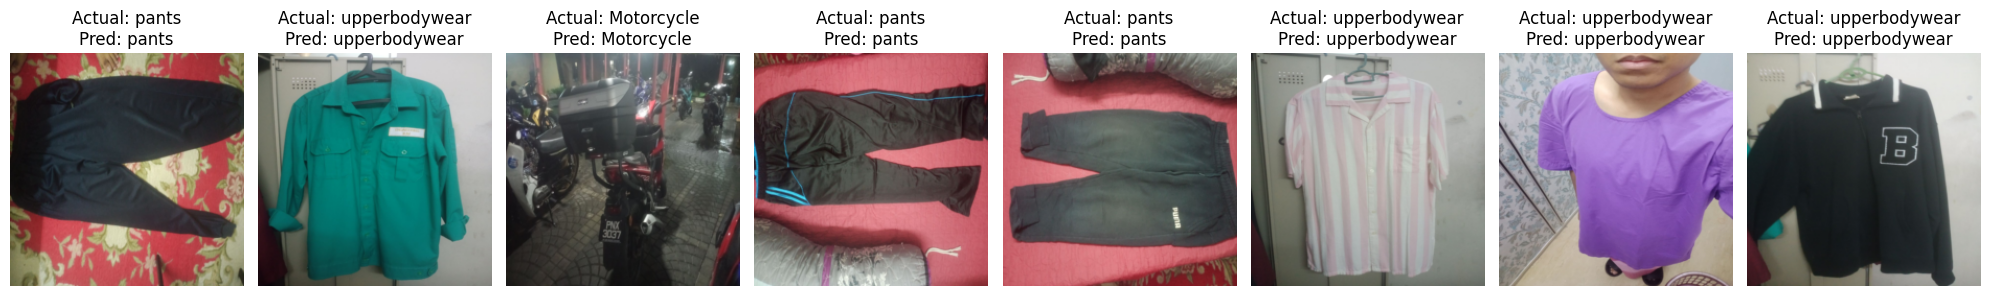

In [88]:
classes = train_dataset.classes

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

# Display multiple predictions
fig, axes = plt.subplots(1, len(images), figsize=(20, 5)) # Create a figure with subplots for each image

for i in range(len(images)): # Loop through all images in the batch
    image = images[i].cpu().permute(1, 2, 0) # Convert tensor to suitable format for matplotlib
    axes[i].imshow(image)
    axes[i].set_title(f"Actual: {classes[labels[i]]}\nPred: {classes[predicted[i]]}")
    axes[i].axis("off") # Turn off axes for cleaner display

plt.tight_layout() # Adjust layout to prevent titles from overlapping
plt.show()